#KERAS SHOLLE SECOND

#Последовательная модель Sequential

In [ ]:

#Самый простой способ создать модель Keras — использовать уже знакомый вам класс моделей Sequential.
#Класс Sequential
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
layers.Dense(64, activation="relu"),
layers.Dense(10, activation="softmax")
])



In [ ]:
#Обратите внимание, что эту модель также можно построить, последовательно вызывая метод add(),
# который действует подобно методу append() списков в языке Python
#Последовательное создание модели Sequential
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

#В главе 4 вы узнали, что слои (точнее, их веса) создаются только в момент первого вызова. Причина подобного поведения в том, что форма слоев зависит от формы входных данных: пока форма входных данных неизвестна, слои не могут быть созданы.
#В силу этого предыдущая модель Sequential не будет иметь весов (листинг 7.3) до передачи ей некоторых данных или до вызова ее метода build() с описанием формы входных данных (листинг 7.4).



In [ ]:
model.weights
#ValueError: Weights for model sequential_1 have not yet been created

[]

In [ ]:
#Первый вызов модели для ее построения

# Этот вызов построит модель — после него модель будет готова принимать образцы с формой (3,).
# """None""" в форме входных данных означает, что размер пакета может быть любымТеперь

model.build(input_shape=(None, 3))
# model.weights
#  [<tf.Variable "dense_2/kernel:0" shape=(3, 64) dtype=float32, ... >,
#   <tf.Variable "dense_2/bias:0" shape=(64,) dtype=float32, ... >
#   <tf.Variable "dense_3/kernel:0" shape=(64, 10) dtype=float32, ... >,
#   <tf.Variable "dense_3/bias:0" shape=(10,) dtype=float32, ... >]

#model.weights[1:10]

for w in model.weights:
    print(f"{w.name}: shape={w.shape}")

  # [tf.Variable "dense_2/kernel:0" shape=(3, 64) dtype=float32,
  #   tf.Variable "dense_2/bias:0" shape=(64,) dtype=float32,
  #   tf.Variable "dense_3/kernel:0" shape=(64, 10) dtype=float32,
  #   tf.Variable "dense_3/bias:0" shape=(10,) dtype=float32]


kernel: shape=(3, 64)
bias: shape=(64,)
kernel: shape=(64, 10)
bias: shape=(10,)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#эта модель получила имя sequential_1. В Keras имя можно присвоить чему угодно — каждой модели, каждому слою.


#Присваивание имен моделям и слоям путем передачи аргумента name
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_last_layer (Dense)           │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#При пошаговом построении модели Sequential удобно иметь возможность посмотреть на ее текущее
#  состояние после добавления очередного слоя. Но сводку невозможно получить,
#  пока модель не построена! Эту проблему можно решить,
#  строя модель Sequential на лету, для чего достаточно заранее объявить форму входных данных.
#  Это можно сделать с помощью класса Input.

In [ ]:
#Предварительное определение формы входных данных модели с помощью класса Input
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))  ##Использование Input для объявления формы входных данных. Обратите внимание, что аргумент shape должен определять форму одного образца, но не пакета
model.add(layers.Dense(64, activation="relu"))

In [ ]:
#Теперь вы сможете вызывать summary() и наблюдать, как меняется форма выходных данных модели по мере добавления дополнительных слоев:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256 (1.00 KB)

 Trainable params: 256 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(layers.Dense(10, activation="softmax"))
model.summary()

# Это довольно распространенный прием отладки при работе со слоями,
# которые применяют сложные преобразования к своим входным данным
#  (например, со сверточными слоями, о которых рассказывается в главе 8

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

#Функциональный API

In [ ]:
#Модель Sequential проста в использовании, но круг сфер ее применения чрезвычайно ограничен:
# она может выражать модели только с одним входом и одним выходом, последовательно применяя
# слои друг за другом. Но на практике довольно часто встречаются модели с несколькими входами
#  (например, изображение и его метаданные), несколькими выходами
#   (разные признаки, которые необходимо предсказать) или нелинейной топологией

In [ ]:
#Создание простой модели с двумя слоями Dense с помощью функционального API
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
from tensorflow.keras import backend as K
K.clear_session()

In [ ]:
#Сначала объявляется форма входных данных в виде экземпляра класса Input (обратите внимание,
#что этим объектам, как и любым другим, тоже можно присваивать имена):
inputs = keras.Input(shape=(3,), name="my_input")

In [ ]:
inputs.shape

(None, 3)

In [ ]:
## (None, 3) -- dtypefloat32Модель будет обрабатывать пакеты, в которых каждый образец имеет форму (3,).
#Количество образцов в пакете может меняться (о чем говорит значение None,
# определяющее размер пакета)


In [ ]:
inputs.dtype  ##Данные в пакетах имеют тип float32

'float32'

In [ ]:
#Такие объекты называются символическими тензорами. Они не содержат никаких действительных данных, но определяют параметры фактических тензоров, которые модель будет получать на входе. То есть они представляют будущие тензоры данных.

In [ ]:
#Затем создается слой и при создании ему передается информация о входных данных:
features = layers.Dense(64, activation="relu")(inputs)

In [ ]:
#Любым слоям Keras могут передаваться тензоры с реальными данными или такие вот символические тензоры. В последнем случае они возвращают новый символический тензор с информацией о форме и типе выходных данных:
features.shape


(None, 64)

In [ ]:
#После получения информации о выходных данных последнего слоя создается экземпляр модели;
#при этом конструктору модели передаются сведения о входах и выходах.
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
## GIVES :   ValueError: The name "my_input" is used 2 times in the model. All operation names should be unique.

# TensorFlow/Keras tracks all named operations in its internal graph. If you define:

# inputs = keras.Input(shape=(3,), name="my_input")
# and run that code more than once without clearing the graph, Keras thinks
# you're trying to create multiple layers with the same name, which isn't allowed.

In [ ]:
# Clear the Keras session (best practice)
# Before re-running model definition code, add:

# from tensorflow.keras import backend as K
# K.clear_session()

In [ ]:
# Or simply:

# keras.backend.clear_session()
# This resets the computation graph and avoids the "name used twice" error.

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Модели с несколькими входами и выходами

In [ ]:
# Представьте, что вы создаете систему для ранжирования заявок в службу поддержки клиентов по важности и для распределения между соответствующими отделами. Ваша модель имеет три входа:
# название заявки (текстовый вход);
# текст с описанием заявки (текстовый вход);
# теги, добавленные пользователем (категориальный вход; предполагается, что теги представлены в формате прямого кодирования).
# Модель также имеет два выхода:
# оценку важности заявки — скалярное значение от 0 до 1 (сигмоидный выход);
# отдел, который должен обработать заявку (результат применения функции softmax к множеству отделов).

In [ ]:
#Создание модели с несколькими входами и выходами с помощью функционального API
vocabulary_size = 10000
num_tags = 100
num_departments = 4
title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body") #Определение входов моделиОбъединение
tags = keras.Input(shape=(num_tags,), name="tags")

features = layers.Concatenate()([title, text_body, tags])  #Объединение входных признаков в один тензор featuresДобавление
features = layers.Dense(64, activation="relu")(features)  #featuresДобавление промежуточного слоя для рекомбинации входных признаков в более богатые представленияОпределение

priority = layers.Dense(1, activation="sigmoid", name="priority")(features) #представленияОпределение выходов модел
department = layers.Dense(num_departments, activation="softmax", name="department")(features)  #представленияОпределение выходов модел
model = keras.Model(inputs=[title, text_body, tags], outputs=[priority, department])  #Создание модели с передачей ей информации о входах и выходах



In [ ]:
#Обучение модели с несколькими входами и выходами

In [ ]:
#Обучение модели с передачей массивов входных данных и целей

import numpy as np
num_samples = 1280
#Фиктивные входные данные
title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))
#данныеФиктивные целевые данные
priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, 2, size=(num_samples, num_departments))

model.compile(optimizer="rmsprop", loss=["mean_squared_error", "categorical_crossentropy"], metrics=[["mean_absolute_error"], ["accuracy"]])
model.fit([title_data, text_body_data, tags_data], [priority_data, department_data], epochs=1)
model.evaluate([title_data, text_body_data, tags_data], [priority_data, department_data])
priority_preds, department_preds = model.predict( [title_data, text_body_data, tags_data])

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - department_accuracy: 0.2959 - department_loss: 51.2003 - loss: 51.4791 - priority_loss: 0.2789 - priority_mean_absolute_error: 0.4442
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - department_accuracy: 0.1415 - department_loss: 41.8458 - loss: 42.1668 - priority_loss: 0.3210 - priority_mean_absolute_error: 0.4862
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
#Обучение модели с передачей массивов входных данных и целей в словаре
model.compile(optimizer="rmsprop",
  loss={"priority": "mean_squared_error",
    "department": "categorical_crossentropy"},

metrics={"priority": ["mean_absolute_error"],
  "department": ["accuracy"]})
model.fit({"title": title_data, "text_body": text_body_data,
  "tags": tags_data},
   {"priority": priority_data, "department": department_data}, epochs=1)
model.evaluate({"title": title_data, "text_body": text_body_data,
  "tags": tags_data},
    {"priority": priority_data, "department": department_data})
priority_preds, department_preds = model.predict(
   {"title": title_data, "text_body": text_body_data, "tags": tags_data})

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - department_accuracy: 0.2701 - department_loss: 89.0582 - loss: 89.3864 - priority_loss: 0.3282 - priority_mean_absolute_error: 0.4955
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - department_accuracy: 0.3419 - department_loss: 43.4188 - loss: 43.7398 - priority_loss: 0.3210 - priority_mean_absolute_error: 0.4862
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
#Обучение модели с передачей массивов входных данных и целей в словаре (2 epoch)
model.compile(optimizer="rmsprop",
  loss={"priority": "mean_squared_error",
    "department": "categorical_crossentropy"},

metrics={"priority": ["mean_absolute_error"],
  "department": ["accuracy"]})
model.fit({"title": title_data, "text_body": text_body_data,
  "tags": tags_data},
   {"priority": priority_data, "department": department_data}, epochs=2)
model.evaluate({"title": title_data, "text_body": text_body_data,
  "tags": tags_data},
    {"priority": priority_data, "department": department_data})
priority_preds, department_preds = model.predict(
   {"title": title_data, "text_body": text_body_data, "tags": tags_data})

Epoch 1/2
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - department_accuracy: 0.2611 - department_loss: 58.9369 - loss: 59.2659 - priority_loss: 0.3290 - priority_mean_absolute_error: 0.4971
Epoch 2/2
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - department_accuracy: 0.2941 - department_loss: 45.8599 - loss: 46.1894 - priority_loss: 0.3294 - priority_mean_absolute_error: 0.4930
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - department_accuracy: 0.6104 - department_loss: 53.3631 - loss: 53.6841 - priority_loss: 0.3210 - priority_mean_absolute_error: 0.4862
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
#Получение входов и выходов слоя в функциональной модели
model.layers
# [<tensorflow.python.keras.engine.input_layer.InputLayer at 0x7fa963f9d358>,
# <tensorflow.python.keras.engine.input_layer.InputLayer at 0x7fa963f9d2e8>,
# <tensorflow.python.keras.engine.input_layer.InputLayer at 0x7fa963f9d470>,
# <tensorflow.python.keras.layers.merge.Concatenate at 0x7fa963f9d860>,
# <tensorflow.python.keras.layers.core.Dense at 0x7fa964074390>,
# <tensorflow.python.keras.layers.core.Dense at 0x7fa963f9d898>,
# <tensorflow.python.keras.layers.core.Dense at 0x7fa963f95470>]
model.layers[3].input
# [<tf.Tensor "title:0" shape=(None, 10000) dtype=float32>,
# <tf.Tensor "text_body:0" shape=(None, 10000) dtype=float32>,
# <tf.Tensor "tags:0" shape=(None, 100) dtype=float32>]
model.layers[3].output
#<tf.Tensor "concatenate/concat:0" shape=(None, 20100) dtype=float32>#

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=concatenate, built=True>,
 <Dense name=dense_2, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

In [ ]:
#Создание новой модели, повторно использующей выходы промежуточных слоев
features = model.layers[4].output
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)
new_model = keras.Model( inputs=[title, text_body, tags], outputs=[priority, department, difficulty])

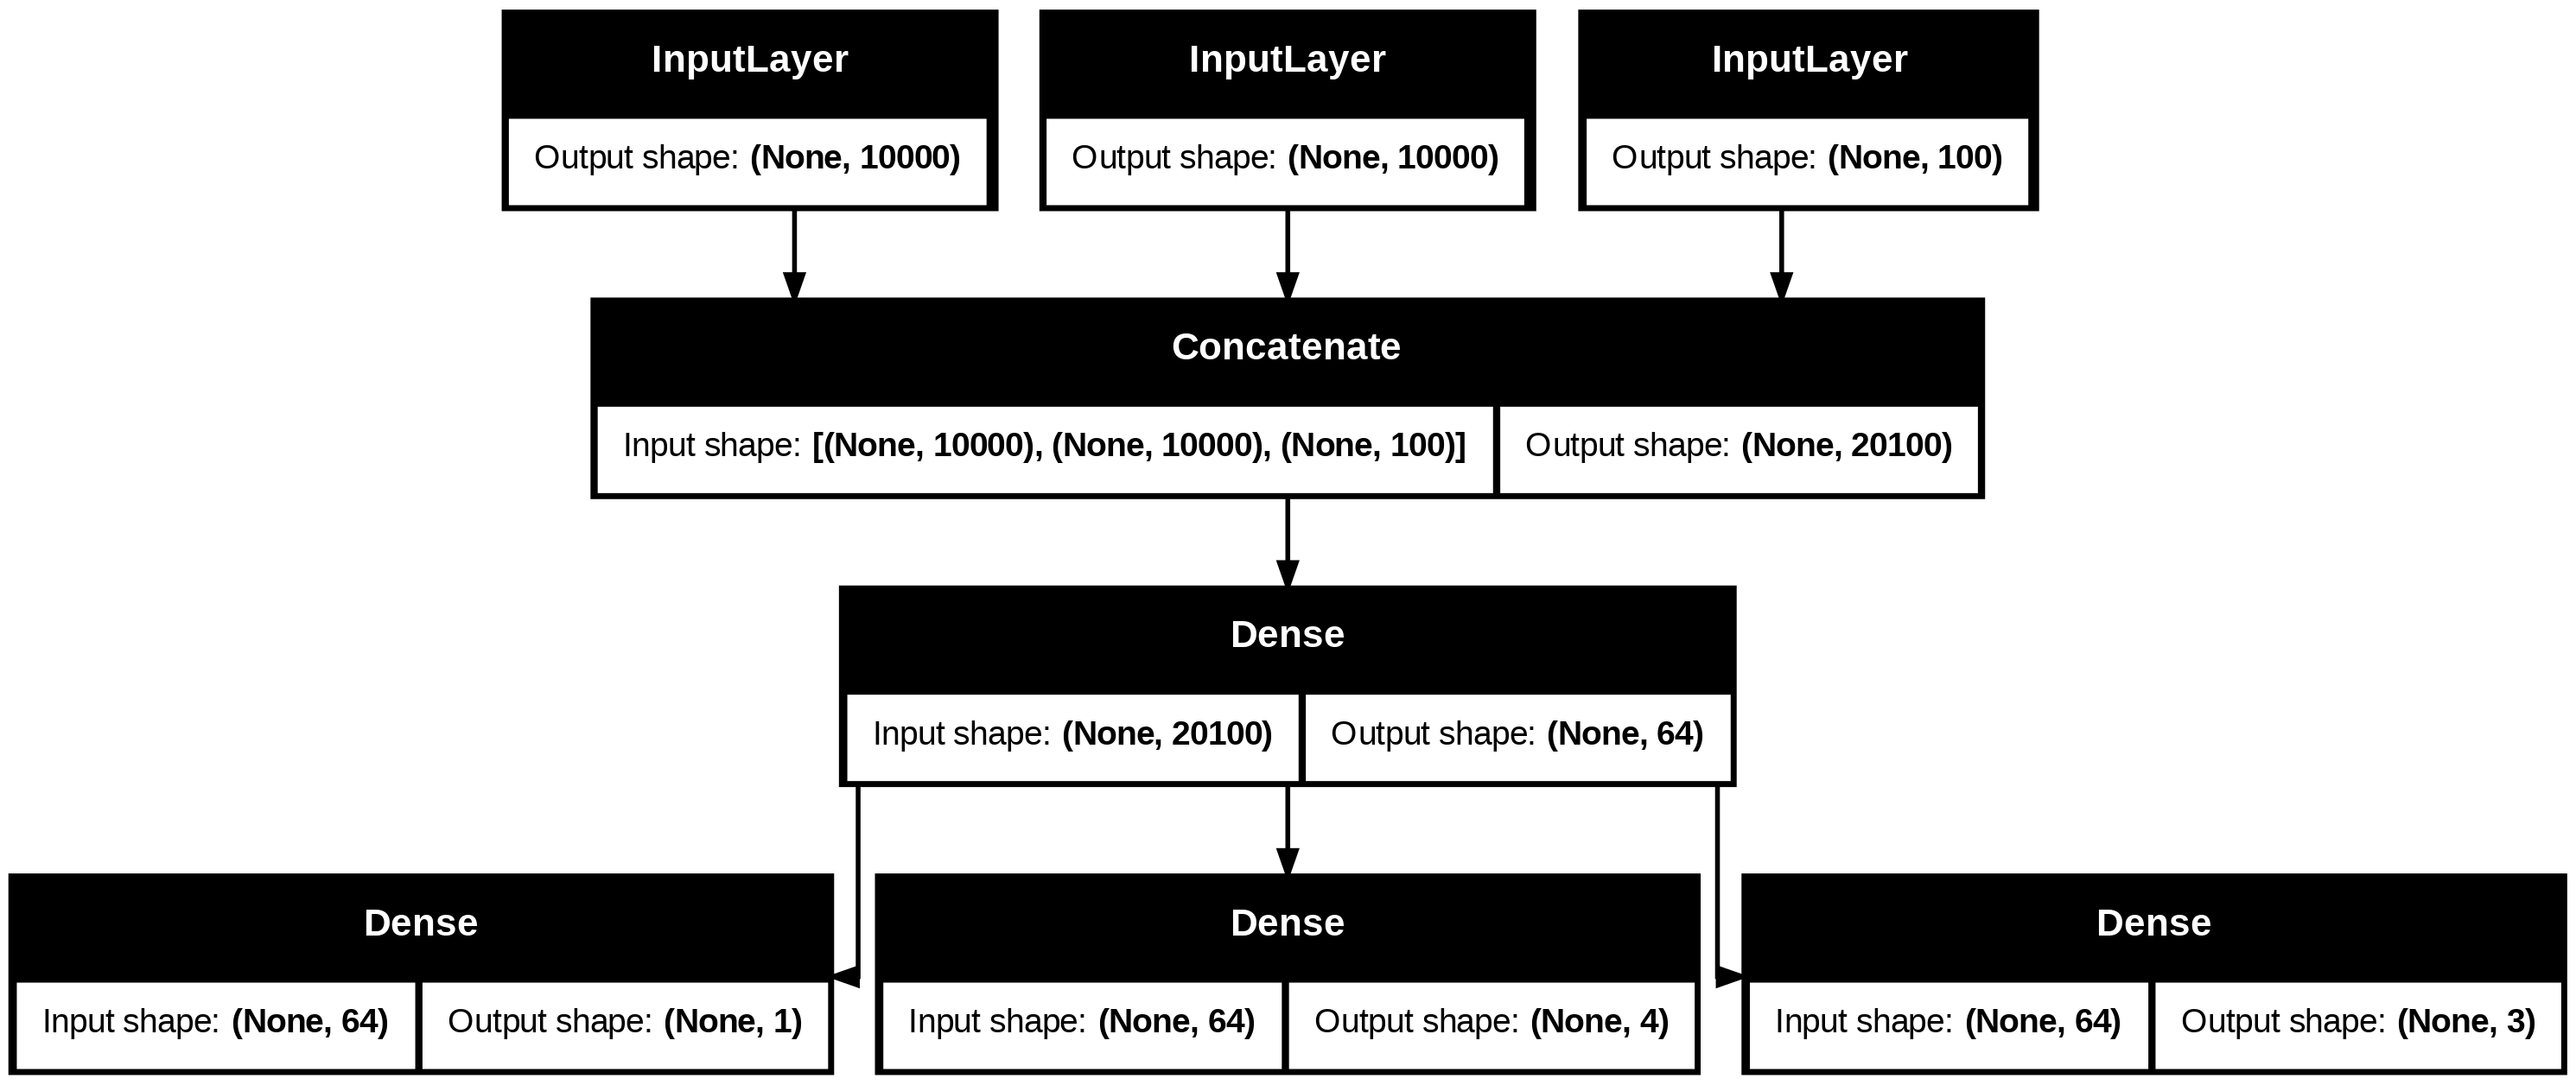

In [ ]:
#Теперь получим графическое представление новой модели:
keras.utils.plot_model(
new_model, "updated_ticket_classifier.png", show_shapes=True)

#Создание производных от класса Model

In [ ]:
# Реализация предыдущего примера созданием производного класса от класса Model
# Рассмотрим простой пример: реализуем модель управления заявками в службу поддержки клиентов, создав производный класс от класса Model.
# Простой подкласс моделей

class CustomerTicketModel(keras.Model):
  def __init__(self, num_departments):
    super().__init__()
    self.concat_layer = layers.Concatenate() #Определите слои в конструкторе
    self.mixing_layer = layers.Dense(64, activation="relu")
    self.priority_scorer = layers.Dense(1, activation="sigmoid")
    self.department_classifier = layers.Dense( num_departments, activation="softmax")

  def call(self, inputs):   #_Определите порядок выполнения прямого прохода в методе call()
    title = inputs["title"]
    text_body = inputs["text_body"]
    tags = inputs["tags"]

    features = self.concat_layer([title, text_body, tags])
    features = self.mixing_layer(features)
    priority = self.priority_scorer(features)
    department = self.department_classifier(features)
    return priority, department

    #Не забудьте вызвать super() — конструктор родительского класса!

In [ ]:
#Определив свой класс моделей, можно создать его экземпляр. Обратите внимание,
#что веса будут созданы только при первом вызове модели с некоторыми данными,
#так же как в подклассах Layer:

model = CustomerTicketModel(num_departments=4)
priority, department = model(
{"title": title_data, "text_body": text_body_data, "tags": tags_data})

In [ ]:
#В чем же тогда разница между подклассом Layer и подклассом Model?

In [ ]:
#Все просто: слой — это просто блок, используемый при строительстве моделей,
#а модель — объект более высокого уровня, который вы будете обучать,
#экспортировать для прогнозирования и т. д. Проще говоря,
#класс Model имеет методы fit(), evaluate() и predict(),
#а у слоев этих методов нет. В остальном данные два класса практически идентичны.
# (Еще одно отличие: модель можно сохранить в файл на диске, о чем мы расскажем несколькими разделами позже.)

In [ ]:
#Компиляция и обучение подкласса Model производятся точно так же, как компиляция последовательных или функциональных моделей:


In [ ]:
model.compile(optimizer="rmsprop",
              loss=["mean_squared_error", "categorical_crossentropy"],
              metrics=[["mean_absolute_error"], ["accuracy"]])  ########Структура аргументов, передаваемых в параметрах loss и metrics, должна точно соответствовать тому, что возвращает call() — в данном случае это списки с двумя элементами
model.fit({"title": title_data, "text_body": text_body_data, "tags": tags_data},
 [priority_data, department_data], epochs=1)
model.evaluate({"title": title_data,
                "text_body": text_body_data, "tags": tags_data}, ###Структура входных данных должна точно соответствовать структуре параметров метода call() — в данном случае это словарь с ключами title, text_body и tagsСтруктура
                 [priority_data, department_data])     ##Структура цели должна точно соответствовать тому, что возвращает метод call(), — в данном случае это список с двумя элементами
priority_preds, department_preds = model.predict({"title": title_data,
                                                  "text_body": text_body_data,
                                                  "tags": tags_data})
#Прием позволяет конструировать модели, которые нельзя выразить в форме ориентированного ациклического графа слоев; представьте, например, модель, в которой метод call() использует слои внутри цикла for или даже вызывает их рекурсивно.

In [ ]:
def outer(x):
    def inner(y):
        return x + y
    return inner

print(outer(5))
#print(add_five = outer(5))
#result = add_five(6)
#print(result)  # prints 11


<function outer.<locals>.inner at 0x7d2b39870b80>


#ВВЕДЕНИЕ В СВЕРТОЧНЫЕ НЕЙРОННЫЕ СЕТИ

In [9]:
#Создание небольшой сверточной нейронной сети

from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)


In [10]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

#cats and dogs

In [11]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"over00","key":"c8c8876df2f2110c491935f5b3dcc9a8"}'}

In [12]:
!mkdir -p ~/.kaggle

In [13]:
!cp kaggle.json ~/.kaggle/

In [14]:
!chmod 600 ~/.kaggle/kaggle.json

In [15]:
!kaggle competitions download -c dogs-vs-cats

 98% 797M/812M [00:03<00:00, 157MB/s]
100% 812M/812M [00:03<00:00, 215MB/s]


In [16]:
!unzip -qq train.zip

unzip:  cannot find or open train.zip, train.zip.zip or train.zip.ZIP.


In [17]:
import os

# Set the root directory where to search (start with /content in Colab)
root_dir = "/content"

# Search for the file
for dirpath, dirnames, filenames in os.walk(root_dir):
    for file in filenames:
        if file == "dogs-vs-cats.zip":
            print("Found at:", os.path.join(dirpath, file))


Found at: /content/dogs-vs-cats.zip


In [18]:
import zipfile
import os

zip_path = "/content/dogs-vs-cats.zip"
extract_path = "/content/dogs-vs-cats"

# Make sure the destination folder exists
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped to:", extract_path)


✅ Unzipped to: /content/dogs-vs-cats


In [19]:
import os

print("Folders inside /content/dogs-vs-cats:")
print(os.listdir("/content/dogs-vs-cats"))

Folders inside /content/dogs-vs-cats:
['sampleSubmission.csv', 'train.zip', 'test1.zip']


In [ ]:
!unzip -qq train.zip

unzip:  cannot find or open train.zip, train.zip.zip or train.zip.ZIP.


In [20]:
!ls -l /content/dogs-vs-cats

total 833952
-rw-r--r-- 1 root root     88903 Jul 12 12:48 sampleSubmission.csv
-rw-r--r-- 1 root root 284321224 Jul 12 12:48 test1.zip
-rw-r--r-- 1 root root 569546721 Jul 12 12:48 train.zip


In [ ]:
!ls -R /content/dogs-vs-cats | head -n 50

/content/dogs-vs-cats:
sampleSubmission.csv
test1.zip
train.zip


In [21]:
import shutil

shutil.rmtree("/content/train", ignore_errors=True)
!unzip -qq /content/dogs-vs-cats/train.zip -d /content/

In [ ]:
# import os

# train_path = "/content/dogs-vs-cats/train"  ##NETU TAKOGO!!!
# sample_images = os.listdir(train_path)[:5]

# print("Sample image files from train set:", sample_images)

In [ ]:
#!unzip -qq /content/dogs-vs-cats/train.zip

replace train/cat.0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [22]:
#Копирование изображений в обучающий, проверочный и контрольный каталоги
import os, shutil, pathlib
original_dir = pathlib.Path("train") ##Путь к каталогу с распакованным исходным набором данныхВспомогательная
new_base_dir = pathlib.Path("cats_vs_dogs_small") ##Каталог для сохранения выделенного небольшого набора

def make_subset(subset_name, start_index, end_index):   ###хВспомогательная функция для копирования изображений кошек (и собак)
#с индексами от start_index до end_index в подкаталог new_base_dir/{subset_name}/cat (и /dog).
#В параметре subset_name будет передаваться строка "train", "validation" или "test"
  for category in ("cat", "dog"):
    dir = new_base_dir / subset_name / category
    os.makedirs(dir)
    fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
    for fname in fnames:
      shutil.copyfile(src=original_dir / fname, dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

#DOGS_VS_CATS again with saving in drive

In [ ]:
# Upload kaggle.json (if not already in Drive)
from google.colab import files
files.upload()

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip
!kaggle competitions download -c dogs-vs-cats -p /content/dogs-vs-cats
!unzip -qq -o /content/dogs-vs-cats/dogs-vs-cats.zip -d /content/dogs-vs-cats
!unzip -qq -o /content/dogs-vs-cats/train.zip -d /content/


Saving kaggle.json to kaggle.json
 96% 782M/812M [00:03<00:00, 193MB/s]
100% 812M/812M [00:04<00:00, 176MB/s]


In [ ]:
#Копирование изображений в обучающий, проверочный и контрольный каталоги
import os, shutil, pathlib
original_dir = pathlib.Path("train") ##Путь к каталогу с распакованным исходным набором данныхВспомогательная
new_base_dir = pathlib.Path("cats_vs_dogs_small") ##Каталог для сохранения выделенного небольшого набора

def make_subset(subset_name, start_index, end_index):   ###хВспомогательная функция для копирования изображений кошек (и собак)
#с индексами от start_index до end_index в подкаталог new_base_dir/{subset_name}/cat (и /dog).
#В параметре subset_name будет передаваться строка "train", "validation" или "test"
  for category in ("cat", "dog"):
    dir = new_base_dir / subset_name / category
    #os.makedirs(dir)
    os.makedirs(dir, exist_ok=True)
    fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
    for fname in fnames:
      shutil.copyfile(src=original_dir / fname, dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

In [ ]:
# Developer info
# Email: drive-file-stream-feedback@google.com
# Clicking "Allow" will redirect you to: https://colab.research.google.com


In [ ]:
#Mount Google Drive first
#Run this before trying to copy anything to Drive:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Example in Colab
#To move images to a new folder:

#import shutil
#shutil.move('/content/image.jpg', '/content/my_images/image.jpg')

#To remove a folder and everything in it:
#shutil.rmtree('/content/temp_folder')


In [ ]:
!cp -r /content/dogs-vs-cats /content/drive/MyDrive/

In [ ]:
!cp -r /content/cats_vs_dogs_small /content/drive/MyDrive/cats_vs_dogs_small

In [ ]:
# copy from MyDrive
# !cp -r /content/drive/MyDrive/cats_vs_dogs_small /content/
# remove from MyDrive
# !mv /content/drive/MyDrive/cats_vs_dogs_small /content/

In [ ]:
#Создание небольшой сверточной нейронной сети для классификации изображений кошек и собак

from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Настройка модели для обучения
model.compile(loss="binary_crossentropy",
optimizer="rmsprop",
metrics=["accuracy"])

In [ ]:
ls /content/cats_vs_dogs_small/test/cat/| head -n 5

cat.1500.jpg
cat.1501.jpg
cat.1502.jpg
cat.1503.jpg
cat.1504.jpg


In [ ]:
#or
import os

folder = "/content/cats_vs_dogs_small/test/cat"
files = os.listdir(folder)
print(files[:3])

['cat.2152.jpg', 'cat.1972.jpg', 'cat.2099.jpg']


#Предварительная обработка данных

In [ ]:
#перед передачей в модель данные должны быть преобразованы в тензоры
# с вещественными числами. В настоящее время данные хранятся в виде файлов JPEG,
# поэтому их нужно подготовить, выполнив следующие шаги.
# 1.
# Прочитать файлы с изображениями.
# 2.
# Декодировать содержимое из формата JPEG в матрицы пикселей RGB.
# 3.
# Преобразовать их в тензоры с вещественными числами.
# 4.
# Привести к единому размеру (в нашем случае 180 × 180).
# 5.
# Организовать в пакеты (мы будем использовать пакеты по 32 изображения в каждом).

In [30]:
#Чтение изображений с помощью функции image_dataset_from_directory
#new_base_dir  - from above:
#new_base_dir = pathlib.Path("cats_vs_dogs_small") ##Каталог для сохранения выделенного небольшого набора


from tensorflow.keras.utils import image_dataset_from_directory
train_dataset = image_dataset_from_directory(
new_base_dir / "train",
image_size=(180, 180),
batch_size=32)
validation_dataset = image_dataset_from_directory(
new_base_dir / "validation",
image_size=(180, 180),
batch_size=32)
test_dataset = image_dataset_from_directory(
new_base_dir / "test",
image_size=(180, 180),
batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [ ]:
# creating a tf.data.Dataset object from the folder cats_vs_dogs_small/train.

# This object:

# Exists in RAM (memory of the Colab virtual machine)

# Contains batches of resized images and their labels

# Is ready to be used for model training or inspection

In [ ]:
ls train_dataset |head -n 6  # no folders for it

ls: cannot access 'train_dataset': No such file or directory


In [ ]:
train_dataset


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 180, 180, 3)
Label batch shape: (32,)


In [ ]:
class_names = train_dataset.class_names
print(class_names)

['cat', 'dog']


In [ ]:
ls /content/cats_vs_dogs_small/test/cat/ | head -n 5

cat.1500.jpg
cat.1501.jpg
cat.1502.jpg
cat.1503.jpg
cat.1504.jpg


In [ ]:
img_path = "/content/cats_vs_dogs_small/train/cat/cat.1500.jpg"

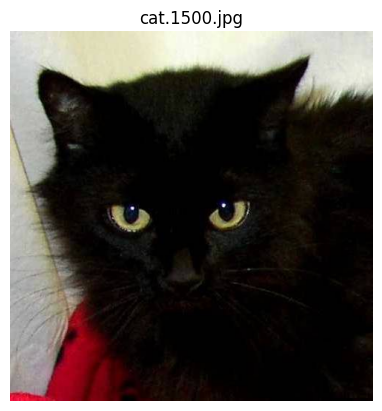

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = "/content/cats_vs_dogs_small/test/cat/cat.1500.jpg"

img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')
plt.title("cat.1500.jpg")
plt.show()

In [ ]:
#Вывод форм данных и меток, возвращаемых объектом Dataset
for data_batch, labels_batch in train_dataset:
  print("data batch shape:", data_batch.shape)
  print("labels batch shape:", labels_batch.shape)
  break
#data batch shape: (32, 180, 180, 3)
#labels batch shape: (32,)

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


#Обучение модели с использованием объекта Dataset

In [29]:
#Обучение модели с использованием объекта Dataset
callbacks = [
keras.callbacks.ModelCheckpoint(
filepath="convnet_from_scratch.keras",
save_best_only=True,
monitor="val_loss")
]
history = model.fit(
train_dataset,
epochs=30,
validation_data=validation_dataset,
callbacks=callbacks)

NameError: name 'train_dataset' is not defined

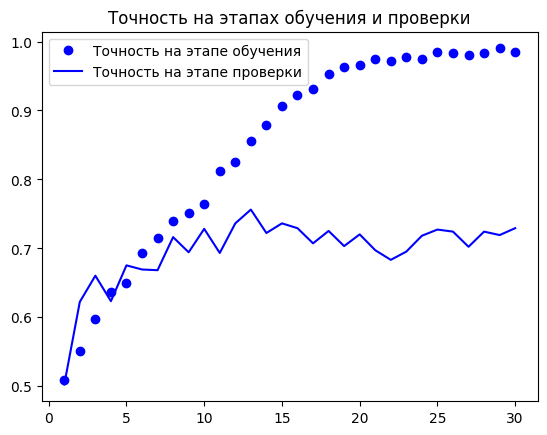

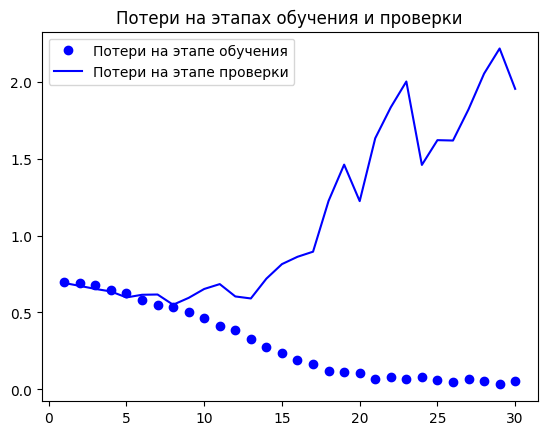

In [ ]:
#Формирование графиков изменения потерь и точности в процессе обучения
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Точность на этапе обучения")
plt.plot(epochs, val_accuracy, "b", label="Точность на этапе проверки")
plt.title("Точность на этапах обучения и проверки")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Потери на этапе обучения")
plt.plot(epochs, val_loss, "b", label="Потери на этапе проверки")
plt.title("Потери на этапах обучения и проверки")
plt.legend()
plt.show()

#non-matching in validation data

In [28]:
import numpy as np

# Turn the test dataset into a list of (image, label) pairs
all_images = []
all_labels = []

for images, labels in validation_dataset.unbatch():
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

all_images = np.array(all_images)
all_labels = np.array(all_labels)


NameError: name 'validation_dataset' is not defined

In [ ]:
pred_probs = model.predict(all_images)
pred_labels = np.argmax(pred_probs, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [ ]:
wrong_indices = np.where(pred_labels != all_labels)[0]

print(f"Found {len(wrong_indices)} misclassified images.")

Found 500 misclassified images.


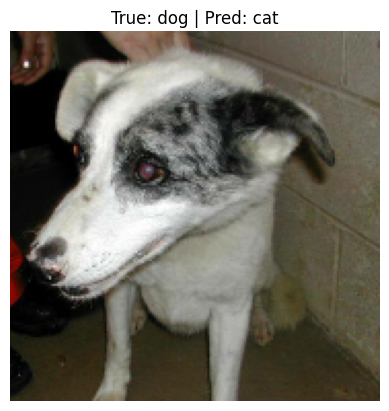

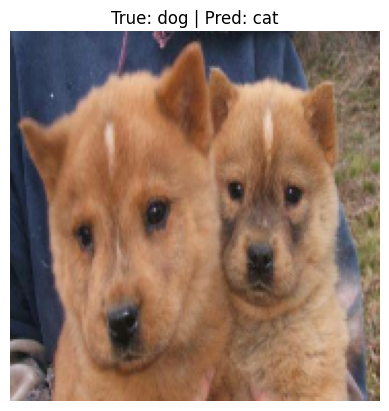

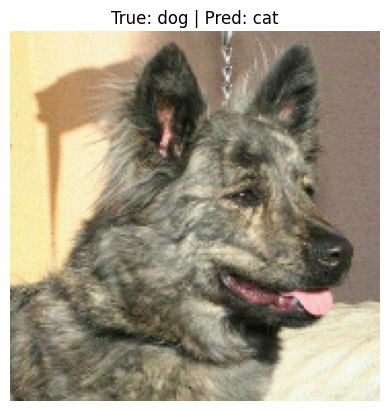

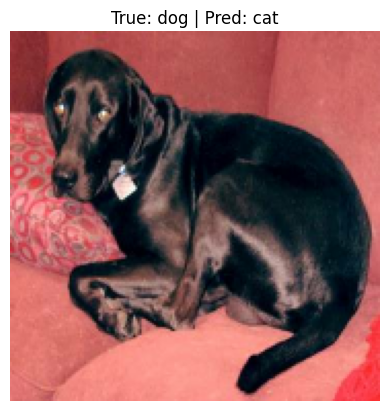

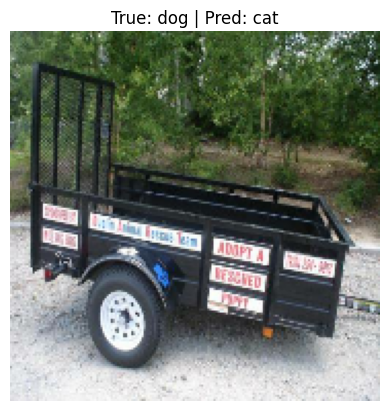

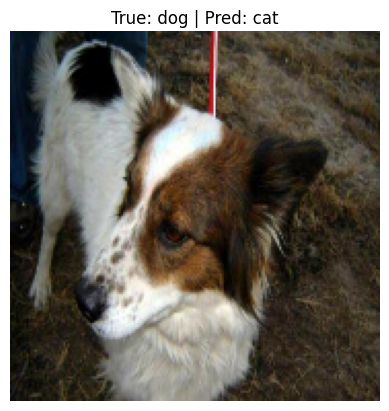

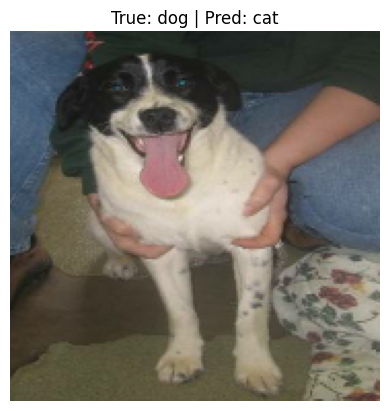

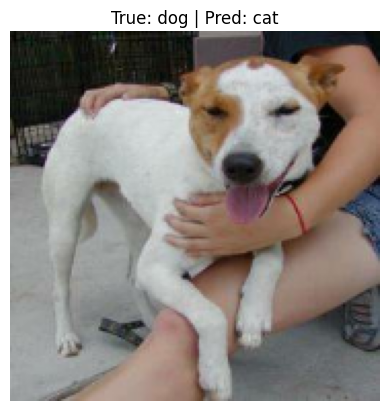

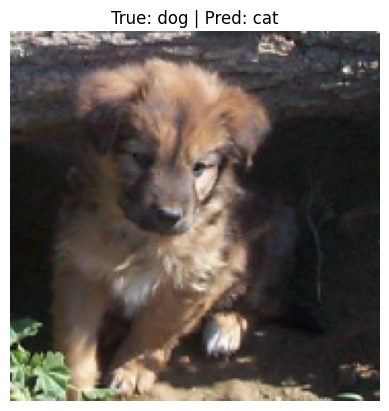

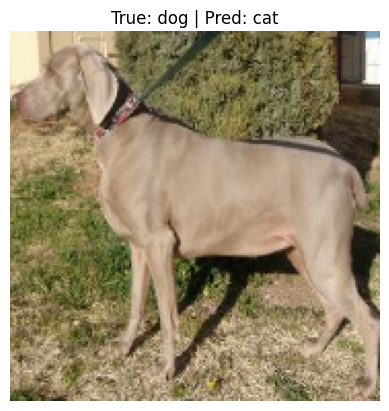

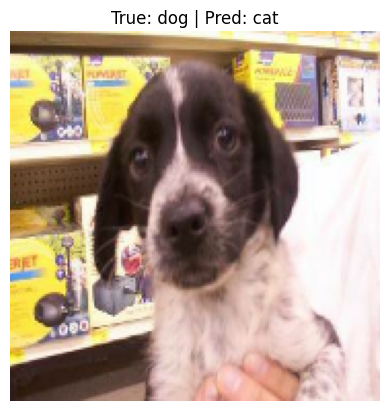

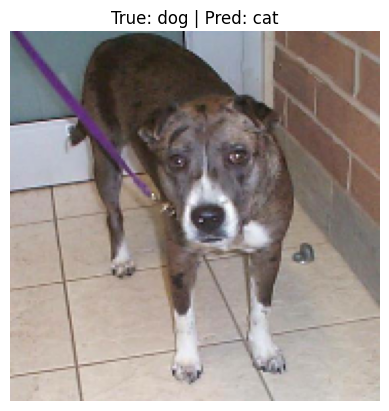

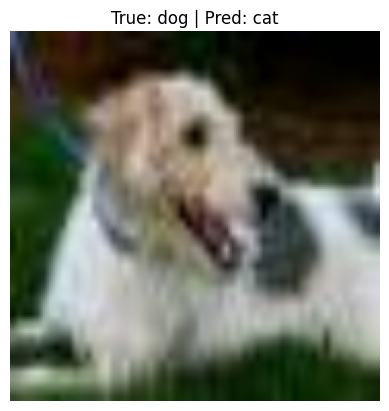

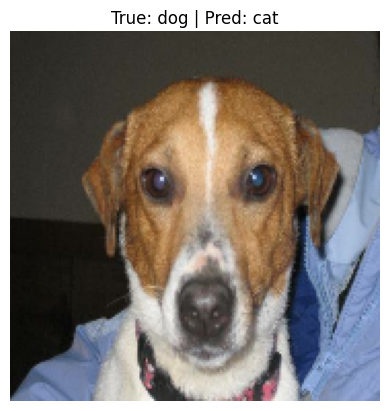

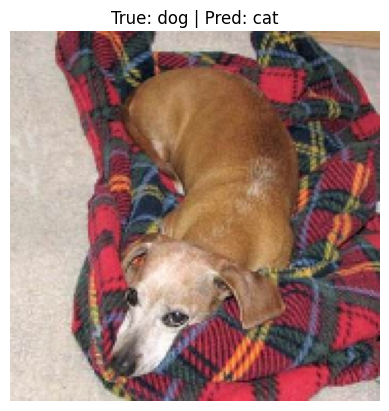

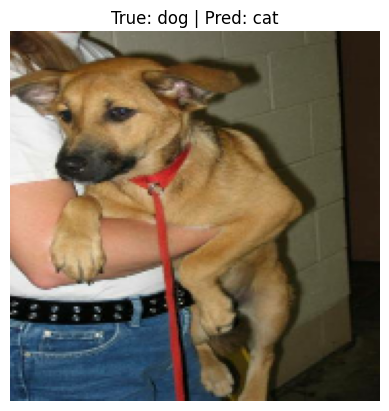

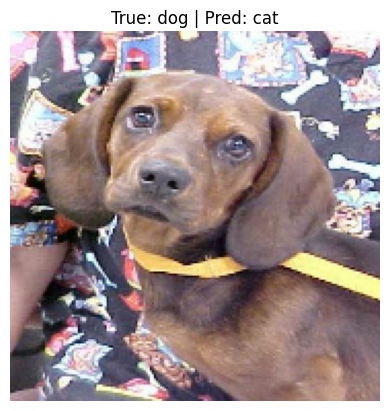

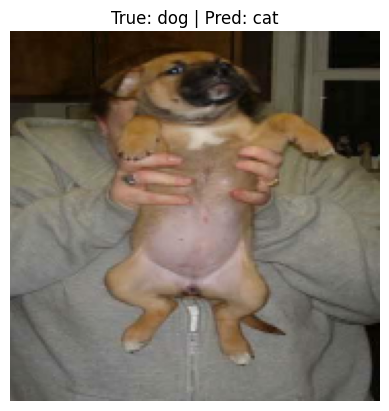

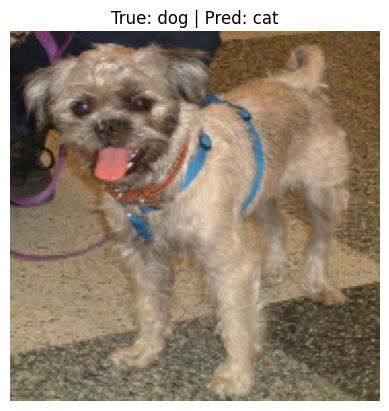

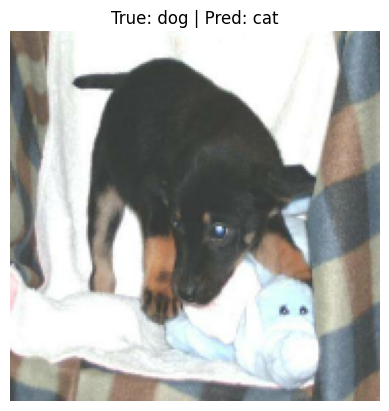

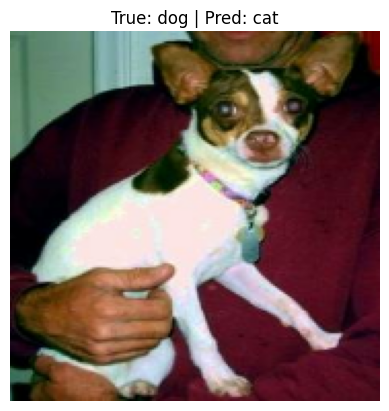

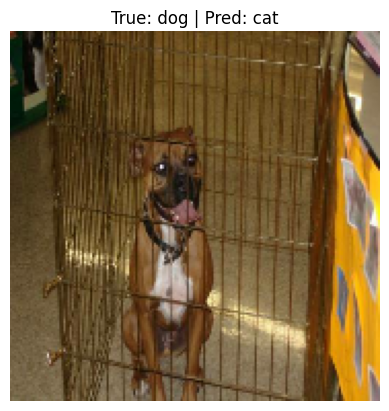

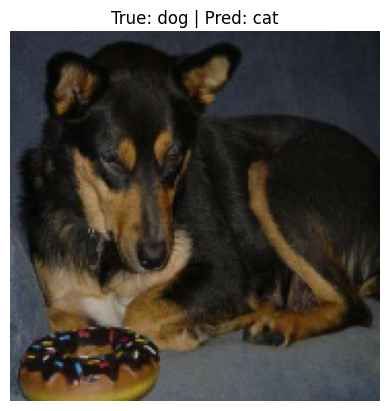

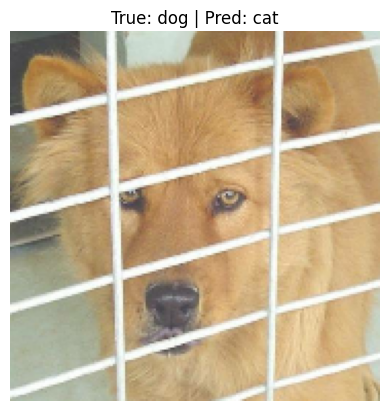

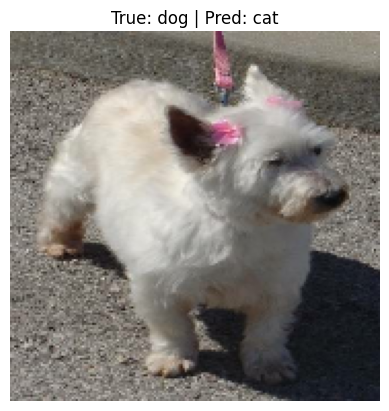

In [ ]:
import matplotlib.pyplot as plt

class_names = test_dataset.class_names  # e.g., ['cat', 'dog']

for i in wrong_indices[:25]:  # show first 5
    plt.imshow(all_images[i].astype("uint8"))
    plt.title(f"True: {class_names[all_labels[i]]} | Pred: {class_names[pred_labels[i]]}")
    plt.axis("off")
    plt.show()

In [ ]:
#Оценка модели на контрольном наборе
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7115 - loss: 0.5850
Test accuracy: 0.714


In [ ]:
#Определение этапа обогащения данных для добавления в модель
data_augmentation = keras.Sequential(
[
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.2),
]
)

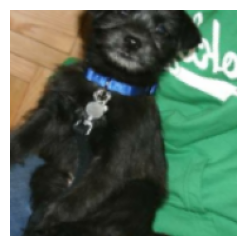

In [ ]:
#Отображение некоторых дополнительных обучающих изображений
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):   #take (N) позволяет выбрать только N пакетов из набора данных. Этот метод действует подобно инструкции break, выполняемой циклом после N-го пакета
  for i in range(9): augmented_images = data_augmentation(images) ##Применить этап обогащения к пакету изображений
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(augmented_images[0].numpy().astype("uint8")) ###Вывести первое изображение в выходном пакете. Во всех девяти итерациях будут получены дополнительные варианты, полученные обогащением одного и того же изображения
  plt.axis("off")

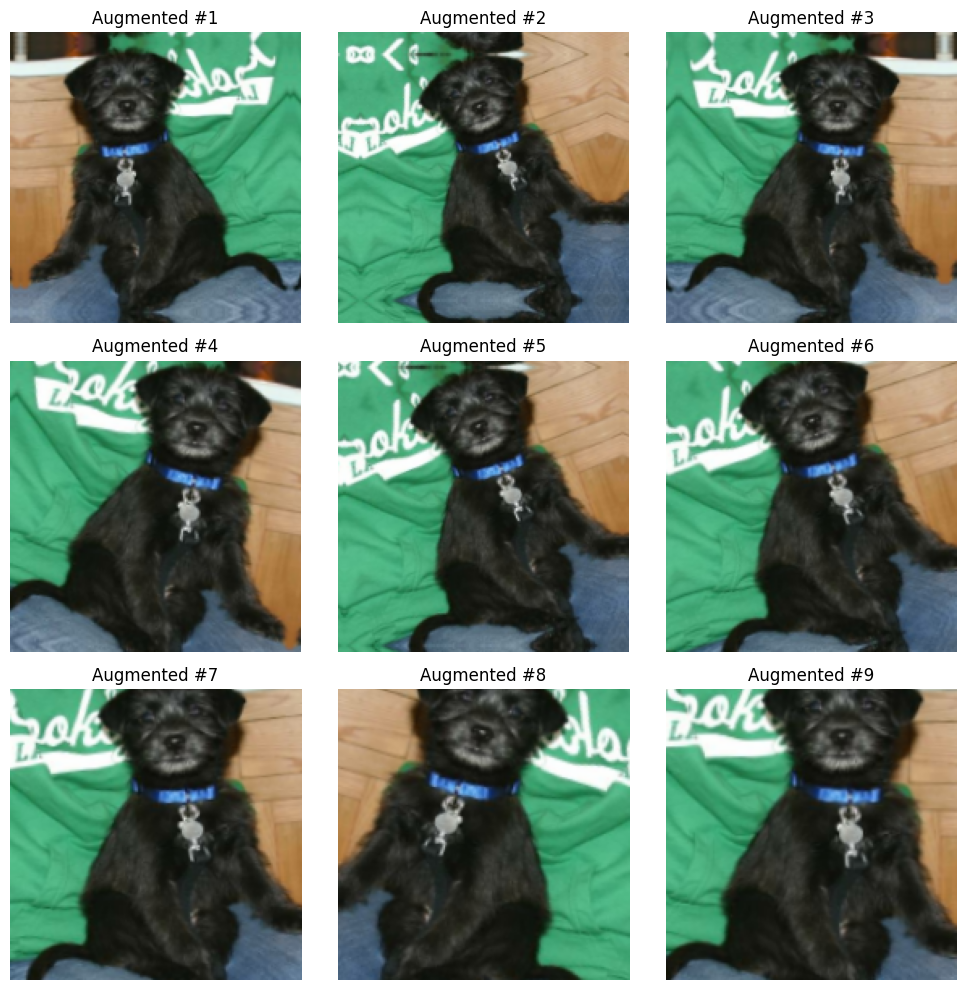

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

for i in range(9):
    augmented_image = data_augmentation(images)
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.title(f"Augmented #{i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()
# 🧠 Notes:
# original_image must be a tensor of shape (1, height, width, 3) — i.e. batched.

# You can create it from a NumPy image like this:

# python
# Copy
# Edit
# import tensorflow as tf

# img_tensor = tf.convert_to_tensor(img_array)           # shape: (height, width, 3)
# original_image = tf.expand_dims(img_tensor, axis=0)    # shape: (1, height, width, 3)
# Let me know if you want to augment a whole batch instead or save the output!












In [ ]:
#Определение новой сверточной нейронной сети с обогащением и прореживанием
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)

x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(loss="binary_crossentropy",
optimizer="rmsprop",
metrics=["accuracy"])

In [ ]:
#Обучение регуляризованной модели
callbacks = [
keras.callbacks.ModelCheckpoint(
filepath="convnet_from_scratch_with_augmentation.keras",
save_best_only=True,
monitor="val_loss")
]
history = model.fit(
train_dataset,
epochs=100,
validation_data=validation_dataset,
callbacks=callbacks)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.5236 - loss: 0.7600 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5111 - loss: 0.6931 - val_accuracy: 0.5030 - val_loss: 0.6912
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.5091 - loss: 0.6952 - val_accuracy: 0.5000 - val_loss: 0.6950
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.5245 - loss: 0.6937 - val_accuracy: 0.5400 - val_loss: 0.6890
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.5752 - loss: 0.6842 - val_accuracy: 0.6450 - val_loss: 0.6693
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5888 - loss: 0.6640 - val_accuracy: 0.5650 - val_loss: 0.6760
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.6294 - loss: 0.6479 - val_accuracy: 0.6200 - val_loss: 0.6566
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.6736 - loss: 0.6191 - val_accuracy: 0.

In [ ]:
import os
print(os.path.exists("convnet_from_scratch_with_augmentation.keras"))

True


In [ ]:
from google.colab import files
files.download("convnet_from_scratch_with_augmentation.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!cp convnet_from_scratch_with_augmentation.keras /content/drive/MyDrive/

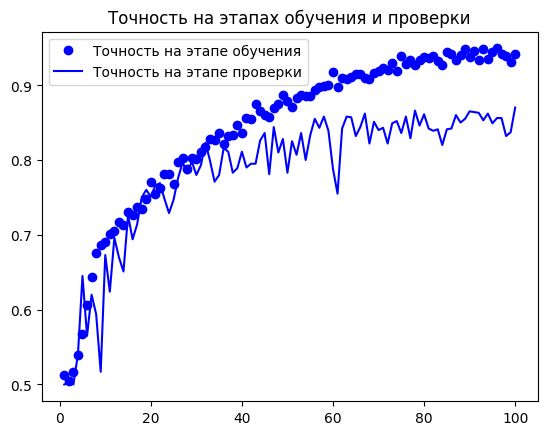

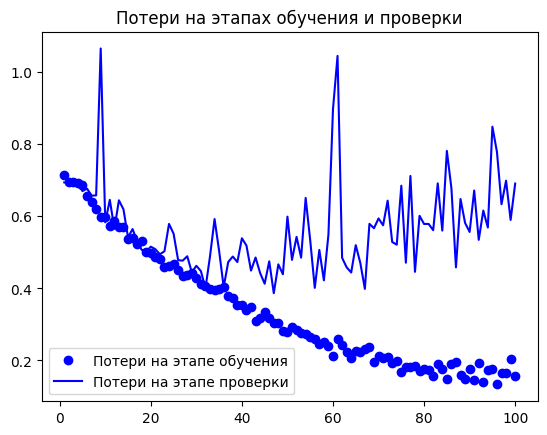

In [ ]:
#Формирование графиков изменения потерь и точности в процессе обучения
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Точность на этапе обучения")
plt.plot(epochs, val_accuracy, "b", label="Точность на этапе проверки")
plt.title("Точность на этапах обучения и проверки")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Потери на этапе обучения")
plt.plot(epochs, val_loss, "b", label="Потери на этапе проверки")
plt.title("Потери на этапах обучения и проверки")
plt.legend()
plt.show()

#VGG16 !!!

In [23]:
#my files were dismounted, let load the scratch model!
from google.colab import files
uploaded = files.upload()

Saving convnet_from_scratch_with_augmentation.keras to convnet_from_scratch_with_augmentation (1).keras


In [2]:
#checking
!ls -lh /content/convnet_from_scratch_with_augmentation.keras

-rw-r--r-- 1 root root 7.7M Jul 12 12:34 /content/convnet_from_scratch_with_augmentation.keras


In [24]:
from tensorflow import keras

model = keras.models.load_model("/content/convnet_from_scratch_with_augmentation.keras")

In [25]:
from tensorflow import keras
from tensorflow.keras import layers

In [26]:
#Создание экземпляра сверточной основы VGG16
conv_base = keras.applications.vgg16.VGG16(
weights="imagenet",
include_top=False,
input_shape=(180, 180, 3))

In [6]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

1.пропустить наш набор данных через сверточную основу, записать получившийся массив NumPy на диск и затем использовать его как входные данные для отдельного полносвязного классификатора (похожего на тот, что мы видели в главе 4 книги). Это быстрое и незатратное решение, потому что требует запускать сверточную основу только один раз для каждого входного изображения, а сверточная основа — самая дорогостоящая часть конвейера. Однако по той же причине этот прием не позволит использовать прием обогащения данных;


2.дополнить имеющуюся модель (conv_base) слоями Dense и пропустить все входные данные. Этот путь позволяет использовать обогащение данных, потому что каждое изображение проходит через сверточную основу каждый раз, когда попадает в модель. Однако по той же причине этот путь намного более затратный, чем первый.

In [31]:
#Сначала рассмотрим код, реализующий первый прием: запись вывода conv_base в ответ на передачу наших данных и его использование в роли входных данных новой модели.
#Сначала выделим признаки в массив NumPy, вызвав метод predict() модели conv_base для обучающих, проверочных и контрольных данных.
#Для этого выполним обход наших наборов данных и выделим признаки VGG16.
#Выделение признаков VGG16 и соответствующих меток


import numpy as np
def get_features_and_labels(dataset):
  all_features = []
  all_labels = []
  for images, labels in dataset:
    preprocessed_images = keras.applications.vgg16.preprocess_input(images)
    features = conv_base.predict(preprocessed_images)
    all_features.append(features)
    all_labels.append(labels)
  return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [32]:
train_features.shape

(2000, 5, 5, 512)

In [34]:
#Определение и обучение полносвязного классификатора
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)  #Обратите внимание! что перед передачей признаков в слой Dense они обрабатываются слоем Flatten
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy", optimizer="rmsprop",
              metrics=["accuracy"])
callbacks = [ keras.callbacks.ModelCheckpoint( filepath="feature_extraction.keras",
                                        save_best_only=True, monitor="val_loss")]

history = model.fit(
train_features, train_labels,
epochs=20,
validation_data=(val_features, val_labels),
callbacks=callbacks)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8821 - loss: 25.3891 - val_accuracy: 0.9700 - val_loss: 4.4127
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9726 - loss: 3.6755 - val_accuracy: 0.9640 - val_loss: 6.6527
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9868 - loss: 1.3334 - val_accuracy: 0.9720 - val_loss: 5.7799
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9820 - loss: 2.9061 - val_accuracy: 0.9740 - val_loss: 4.3019
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9933 - loss: 1.6601 - val_accuracy: 0.9750 - val_loss: 5.2769
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9961 - loss: 0.3053 - val_accuracy: 0.9730 - val_loss: 5.8612
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9975 - loss: 0.1732 - val_accuracy: 0.9540 - val_loss: 10.5025
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9935 - loss: 0.5801 - val_accuracy: 0.9780 - val_lo

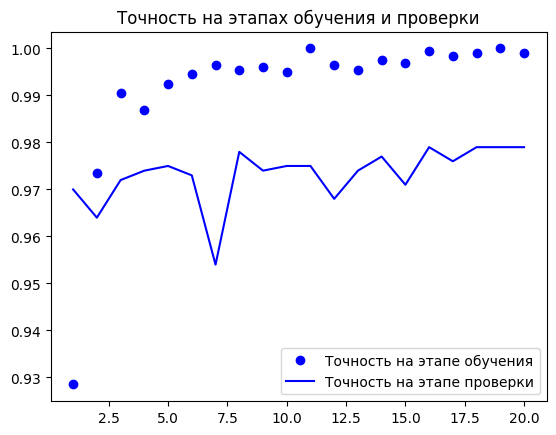

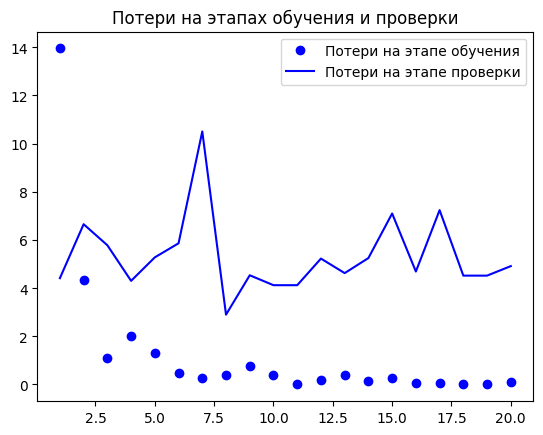

In [35]:
#Построение графиков с результатами
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Точность на этапе обучения")
plt.plot(epochs, val_acc, "b", label="Точность на этапе проверки")
plt.title("Точность на этапах обучения и проверки")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Потери на этапе обучения")
plt.plot(epochs, val_loss, "b", label="Потери на этапе проверки")
plt.title("Потери на этапах обучения и проверки")
plt.legend()
plt.show()

графики показывают, что почти с самого начала стал проявляться эффект переобучения, несмотря на выбор довольно большого коэффициента прореживания. Это объясняется тем, что в данном примере мы не использовали обогащение данных, которое необходимо для предотвращения переобучения на небольших наборах изображений.

In [36]:
#Выделение признаков с обогащением данных

In [36]:
#второй прием выделения признаков, более медленный и затратный,
# но позволяющий использовать обогащение данных в процессе обучения,
# — объединение модели conv_base с новым полносвязным классификатором
# и ее полноценное обучение

In [ ]:
#заморозим сверточную основу!

In [37]:
#Создание и заморозка сверточной основы
conv_base = keras.applications.vgg16.VGG16(
weights="imagenet",
include_top=False)
conv_base.trainable = False

In [39]:
#Вывод списка обучаемых весов до и после заморозки
conv_base.trainable = True
print("This is the number of trainable weights "
"before freezing the conv base:", len(conv_base.trainable_weights))
#This is the number of trainable weights before freezing the conv base: 26

conv_base.trainable = False
print("This is the number of trainable weights "
"after freezing the conv base:", len(conv_base.trainable_weights))
#This is the number of trainable weights after freezing the conv base: 0

This is the number of trainable weights before freezing the conv base: 26
This is the number of trainable weights after freezing the conv base: 0


создадим новую модель, объединяющую следующее.
1.
Этап обогащения данных.
2.
Замороженную сверточную основу.
3.
Полносвязный классификатор.

In [41]:
#Добавление этапа обогащения данных и классификатора к сверточной основе
data_augmentation = keras.Sequential( [ layers.RandomFlip("horizontal"),
                          layers.RandomRotation(0.1), layers.RandomZoom(0.2),])

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)  #Обогащение данных
x = keras.applications.vgg16.preprocess_input(x)  #Масштабирование входных данных
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop", metrics=["accuracy"])



In [ ]:
#ПРИМЕЧАНИЕ
#Этот прием настолько затратный, что его следует применять только при наличии
#доступа к GPU (например, к бесплатному GPU в Colab) — он абсолютно не под силу CPU.
#Если у вас нет возможности запустить свой код на GPU,
#то первый путь остается для вас единственным доступным решением

In [42]:
callbacks = [
keras.callbacks.ModelCheckpoint(
filepath="feature_extraction_with_data_augmentation.keras",
save_best_only=True,
monitor="val_loss")
]
history = model.fit(
train_dataset,
epochs=50,
validation_data=validation_dataset,
callbacks=callbacks)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 209ms/step - accuracy: 0.8196 - loss: 55.9775 - val_accuracy: 0.9230 - val_loss: 15.1999
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.9441 - loss: 6.2154 - val_accuracy: 0.9740 - val_loss: 3.6037
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.9337 - loss: 7.7920 - val_accuracy: 0.9680 - val_loss: 4.0130
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step - accuracy: 0.9661 - loss: 5.0172 - val_accuracy: 0.9820 - val_loss: 2.9111
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - accuracy: 0.9695 - loss: 3.5169 - val_accuracy: 0.9750 - val_loss: 3.0143
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.9714 - loss: 3.2694 - val_accuracy: 0.9640 - val_loss: 6.6928
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.9704 - loss: 3.5432 - val_accuracy: 0.9770 - val_loss: 2.9528
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.9670 - loss: 3.7551 - val_acc

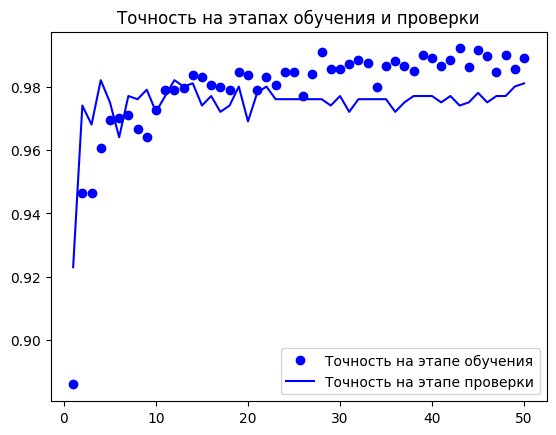

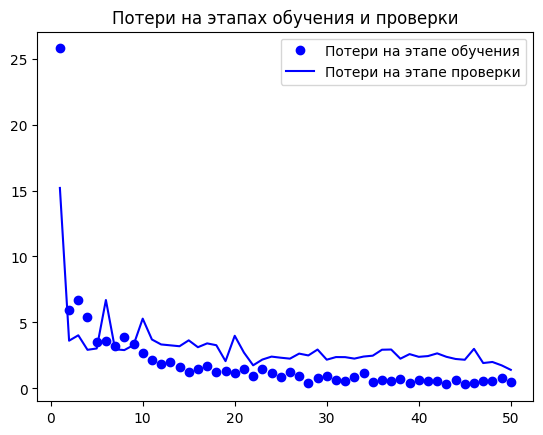

In [43]:
#Построение графиков с результатами
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Точность на этапе обучения")
plt.plot(epochs, val_acc, "b", label="Точность на этапе проверки")
plt.title("Точность на этапах обучения и проверки")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Потери на этапе обучения")
plt.plot(epochs, val_loss, "b", label="Потери на этапе проверки")
plt.title("Потери на этапах обучения и проверки")
plt.legend()
plt.show()
#превысили уровень точности 98 % на этапе проверки!

In [44]:
#Оценка модели на контрольном наборе данных
test_model = keras.models.load_model(
"feature_extraction_with_data_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")
#довольно скромное улучшение  87.8

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.9762 - loss: 1.7435
Test accuracy: 0.978


#Дообучение предварительно обученной модели

In [ ]:
#дообучение (fine-tuning)  Дообучение заключается в размораживании
#нескольких верхних слоев замороженной модели, которая использовалась для выделения
#признаков, и совместном обучении вновь добавленной части модели
 #(в данном случае полносвязного классификатора) и этих верхних слоев.
 #Данный прием называется дообучением

In [45]:
#Замораживание всех слоев, кроме заданных
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
  layer.trainable = False

In [46]:
#Дообучение модели
model.compile(loss="binary_crossentropy",
optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
metrics=["accuracy"])
callbacks = [
keras.callbacks.ModelCheckpoint(
filepath="fine_tuning.keras",
save_best_only=True,
monitor="val_loss")
]
history = model.fit(
train_dataset,
epochs=30,
validation_data=validation_dataset,
callbacks=callbacks)


Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 221ms/step - accuracy: 0.9872 - loss: 0.4899 - val_accuracy: 0.9820 - val_loss: 1.3195
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.9900 - loss: 0.2027 - val_accuracy: 0.9730 - val_loss: 1.9600
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.9887 - loss: 0.3499 - val_accuracy: 0.9810 - val_loss: 1.4549
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.9858 - loss: 0.3868 - val_accuracy: 0.9800 - val_loss: 1.2891
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.9908 - loss: 0.1800 - val_accuracy: 0.9800 - val_loss: 1.3158
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.9883 - loss: 0.1911 - val_accuracy: 0.9780 - val_loss: 1.3644
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.9953 - loss: 0.1308 - val_accuracy: 0.9780 - val_loss: 1.2763
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 216ms/step - accuracy: 0.9896 - loss: 0.2601 - val_accu

In [47]:
#Закончив обучение, оценим модель на контрольных данных:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.9800 - loss: 1.0615
Test accuracy: 0.976


In [1]:
#simple example showing how to visualize feature maps (activations) from a pre-trained model like VGG16 in Colab

# # important about ACTIVATIONS (featiures part)
# #Step-by-step: Visualizing CNN Feature Maps
# #1️⃣ Set up VGG16 without the top layer:

# from tensorflow import keras
# import matplotlib.pyplot as plt
# import numpy as np

# conv_base = keras.applications.VGG16(weights="imagenet", include_top=False, input_shape=(180, 180, 3))

# #then

# #2️⃣ Load and preprocess a sample image:
# from tensorflow.keras.utils import load_img, img_to_array

# img_path = "/content/cats_vs_dogs_small/train/cat/cat.1500.jpg"  # Adjust your path
# img = load_img(img_path, target_size=(180, 180))
# img_array = img_to_array(img)
# img_array = np.expand_dims(img_array, axis=0)
# img_array = keras.applications.vgg16.preprocess_input(img_array)
# #3️⃣ Get feature maps:
# #feature_maps = conv_base.predict(img_array)
# print("Feature maps shape:", feature_maps.shape)
# #For VGG16, it will usually show something like (1, 5, 5, 512).

# #4️⃣ Visualize a few feature maps:
# # Pick one set of feature maps

# first_feature_map = feature_maps[0]

# plt.figure(figsize=(12, 12))

# for i in range(9):  # Show first 9 feature channels
#     plt.subplot(3, 3, i + 1)
#     plt.imshow(first_feature_map[:, :, i], cmap='viridis')
#     plt.axis('off')
#     plt.title(f'Feature map {i}')

# plt.tight_layout()
# plt.show()
# # ✅ Notes:
# # Each subplot shows one channel (filter output) from the last convolutional layer.

# # Bright spots = strong activations → where the model sees patterns.

# #  I need  set up the same for intermediate layers
# #  (not just the last one) to compare how early vs. late layers look.
# #  That will be helpful!!!

#---------------------
# “Features are the high-level representations (activations)”

# It means:

# You give an image to the model.

# The convolutional layers apply many filters:
# Detecting things like edges, textures, corners, patterns, and object parts.

# Each filter produces an output — these outputs are called activations.

#Collectively, all these activations across all filters and layers are called features.









